In [ ]:
import pandas as pd
import numpy as np

DATA DESCRIPTION
```
file name -> Columns
quater-i.csv -> ['order_id', 'quantity', 'item_id', 'choice_description_id' 'item_price']
items.csv -> ['item_id', 'item_name']
```
Dataset Link - https://drive.google.com/drive/folders/1Z0kaFybvgFeczeUj4dldUnhTdloLqLsL?usp=share_link

In [ ]:
# import like this
#

###`Q:1-5`
1. You are given three quater files, your job is to append these three files and make a single dataframe.
2. Have a index as Q-1 Q-2 Q-3 for respective quater files in the dataframe
3. Your are given a file items.csv which has item_id and item_name. Find out most sold items in each quarter.
4. Find out items which has made most revenue in each quarter.
5. Find out avg order price of each quarter.

***Note: item_price is given as str with $ sign, in earlier task you have converted this to rupees, here too first convert item_price field in rupees.***

In [ ]:
# code here

###`Q-6` From the IPL wala dataset you have to find the Purple cap holder each season.

*Note: Bowler with most no wickets in a season gets purple cap. If more than one bowler have same no of wickets in the season, one with least ecomnomy among them is purple cap holder.*

Bowler's Economy = runs-conceded per six balls

In [ ]:
ipl_ball_by_ball = pd.read_csv('/content/IPL_Ball_by_Ball_2008_2022.csv')
ipl_matches = pd.read_csv('/content/IPL_Matches_2008_2022.csv')

In [ ]:
wickets = ipl_ball_by_ball[(
    (ipl_ball_by_ball['kind'].isin(['bowled','caught','caught and bowled','lbw','stumped','hit wicket']))
    )]
wickets = wickets.merge(
    ipl_matches[['ID', 'Season']],
    on='ID'
)
wickets = (
    wickets
    .groupby(['Season', 'bowler'])
    .size()
    .reset_index(name='wickets')
)
wickets

,Season,bowler,wickets
0,2007/08,A Kumble,7
1,2007/08,A Mishra,11
2,2007/08,A Nehra,12
3,2007/08,A Nel,1
4,2007/08,AA Noffke,1
...,...,...,...
1375,2022,VG Arora,3
1376,2022,VR Aaron,2
1377,2022,Washington Sundar,6
1378,2022,YS Chahal,27


In [ ]:
legal_balls = ipl_ball_by_ball[~(ipl_ball_by_ball['extra_type'].isin(['wides', 'noballs']))]
balls = (
    legal_balls
    .merge(ipl_matches[['ID', 'Season']], on='ID')
    .groupby(['Season', 'bowler'])
    .size()
    .reset_index(name='balls')
)
balls

,Season,bowler,balls
0,2007/08,A Kumble,230
1,2007/08,A Mishra,119
2,2007/08,A Nehra,269
3,2007/08,A Nel,18
4,2007/08,A Symonds,41
...,...,...,...
1668,2022,VR Iyer,24
1669,2022,Washington Sundar,168
1670,2022,YBK Jaiswal,1
1671,2022,YS Chahal,408


In [ ]:
# total_runs
runs_df = ipl_ball_by_ball[~(ipl_ball_by_ball['extra_type'].isin(['legbyes', 'byes']))]
runs = (
    runs_df
    .merge(ipl_matches[['ID', 'Season']], on='ID')
    .groupby(['Season', 'bowler'])['total_run']
    .sum()
    .reset_index(name='runs')
)
runs

,Season,bowler,runs
0,2007/08,A Kumble,304
1,2007/08,A Mishra,138
2,2007/08,A Nehra,348
3,2007/08,A Nel,31
4,2007/08,A Symonds,101
...,...,...,...
1668,2022,VR Iyer,46
1669,2022,Washington Sundar,239
1670,2022,YBK Jaiswal,6
1671,2022,YS Chahal,527


In [ ]:
economy = balls.merge(runs, on=['Season', 'bowler'])
economy['economy'] = economy['runs'] * 6 / economy['balls']
economy.groupby(['Season','bowler'])
economy.sort_values(['Season', 'economy']).head(20)

,Season,bowler,balls,runs,economy
85,2007/08,TM Dilshan,6,3,3.000000
23,2007/08,DJ Thornely,42,40,5.714286
14,2007/08,BAW Mendis,24,24,6.000000
64,2007/08,RG Sharma,24,25,6.250000
73,2007/08,SC Ganguly,120,128,6.400000
84,2007/08,Sohail Tanvir,247,266,6.461538
78,2007/08,SM Pollock,276,301,6.543478
34,2007/08,IK Pathan,318,350,6.603774
30,2007/08,GD McGrath,324,357,6.611111
29,2007/08,DW Steyn,228,252,6.631579


In [ ]:
purple = wickets.merge(economy, on=['Season', 'bowler'])
purple = purple.sort_values(
    ['Season', 'wickets', 'economy'],
    ascending=[True, False, True]
)
purple_cap = purple.groupby('Season').head(1)
purple_cap[['Season', 'bowler', 'wickets', 'economy']]

,Season,bowler,wickets,economy
75,2007/08,Sohail Tanvir,22,6.461538
152,2009,RP Singh,23,6.988827
241,2009/10,PP Ojha,21,7.291785
367,2011,SL Malinga,28,5.952381
437,2012,M Morkel,25,7.190476
509,2013,DJ Bravo,32,7.952000
638,2014,MM Sharma,23,8.396285
694,2015,DJ Bravo,26,8.140127
773,2016,B Kumar,23,7.424242
860,2017,B Kumar,26,7.050955


In [ ]:
##
'''
temp_df = wickets.merge(ipl_matches,on="ID")
temp_x = temp_df.groupby(['Season','bowler']).size().reset_index(name='wickets').sort_values(['Season','wickets'],ascending=[True,False]).groupby('Season').head(1)
purple_cap_df = temp_x.merge(economy,on='bowler').sort_values(['Season', 'wickets', 'economy'], ascending=[True, False, True])
purple_cap_holders = purple_cap_df.groupby('Season').head(1)
purple_cap_holders
'''
##

'\ntemp_df = wickets.merge(ipl_matches,on="ID")\ntemp_x = temp_df.groupby([\'Season\',\'bowler\']).size().reset_index(name=\'wickets\').sort_values([\'Season\',\'wickets\'],ascending=[True,False]).groupby(\'Season\').head(1)\npurple_cap_df = temp_x.merge(economy,on=\'bowler\').sort_values([\'Season\', \'wickets\', \'economy\'], ascending=[True, False, True])\npurple_cap_holders = purple_cap_df.groupby(\'Season\').head(1)\npurple_cap_holders\n'

###`Q-7:` Best bowler in death overs.
*Note: Have taken most no of wickets in case of tie with least economy*

Death Overs - [16-20]

In [ ]:
# code here

In [ ]:
ipl_matches = pd.read_csv('/content/IPL_Matches_2008_2022.csv')
ipl_ball_by_ball = pd.read_csv('/content/IPL_Ball_by_Ball_2008_2022.csv')
ipl_ball_by_ball.head()

,ID,innings,overs,ballnumber,batter,bowler,non-striker,extra_type,batsman_run,extras_run,total_run,non_boundary,isWicketDelivery,player_out,kind,fielders_involved,BattingTeam
0,1312200,1,0,1,YBK Jaiswal,Mohammed Shami,JC Buttler,NaN,0,0,0,0,0,NaN,NaN,NaN,Rajasthan Royals
1,1312200,1,0,2,YBK Jaiswal,Mohammed Shami,JC Buttler,legbyes,0,1,1,0,0,NaN,NaN,NaN,Rajasthan Royals
2,1312200,1,0,3,JC Buttler,Mohammed Shami,YBK Jaiswal,NaN,1,0,1,0,0,NaN,NaN,NaN,Rajasthan Royals
3,1312200,1,0,4,YBK Jaiswal,Mohammed Shami,JC Buttler,NaN,0,0,0,0,0,NaN,NaN,NaN,Rajasthan Royals
4,1312200,1,0,5,YBK Jaiswal,Mohammed Shami,JC Buttler,NaN,0,0,0,0,0,NaN,NaN,NaN,Rajasthan Royals


In [ ]:
wickets = ipl_ball_by_ball[((ipl_ball_by_ball['overs'] > 15) & (ipl_ball_by_ball['kind'].isin(['bowled','caught','caught and bowled','lbw','stumped','hit wicket'])))]
total_wickets = wickets.merge(ipl_matches,on='ID').groupby(['Season','bowler']).size().reset_index(name='wickets')

In [ ]:
balls = ipl_ball_by_ball[~ipl_ball_by_ball['extra_type'].isin(['wides', 'noballs']) & ipl_ball_by_ball['overs'].between(16, 20)]
legal_balls = balls.merge(ipl_matches,on='ID').groupby(['Season','bowler']).size().reset_index(name='legal_balls')
legal_balls

,Season,bowler,legal_balls
0,2007/08,A Kumble,14
1,2007/08,A Mishra,6
2,2007/08,A Nehra,47
3,2007/08,A Nel,6
4,2007/08,A Symonds,5
...,...,...,...
1179,2022,VR Iyer,12
1180,2022,Washington Sundar,12
1181,2022,YBK Jaiswal,1
1182,2022,YS Chahal,78


In [ ]:
runs = ipl_ball_by_ball[~ipl_ball_by_ball['extra_type'].isin(['byes','legbyes']) & ipl_ball_by_ball['overs'].between(16, 20)]
runs_conceded = runs.merge(ipl_matches,on='ID').groupby(['Season','bowler'])['total_run'].sum().reset_index(name='runs_conceded')
runs_conceded

,Season,bowler,runs_conceded
0,2007/08,A Kumble,40
1,2007/08,A Mishra,2
2,2007/08,A Nehra,83
3,2007/08,A Nel,8
4,2007/08,A Symonds,19
...,...,...,...
1180,2022,VR Iyer,24
1181,2022,Washington Sundar,37
1182,2022,YBK Jaiswal,6
1183,2022,YS Chahal,123


In [ ]:
temp_df = legal_balls.merge(runs_conceded,on=['Season','bowler']).merge(total_wickets,on=['Season','bowler'])
temp_df['economy'] = (
    temp_df['runs_conceded'] * 6
    / temp_df['legal_balls']
)
temp_df

,Season,bowler,legal_balls,runs_conceded,wickets,economy
0,2007/08,A Mishra,6,2,3,2.000000
1,2007/08,A Nehra,47,83,2,10.595745
2,2007/08,AA Noffke,6,7,1,7.000000
3,2007/08,AB Agarkar,12,11,2,5.500000
4,2007/08,B Akhil,8,16,1,12.000000
...,...,...,...,...,...,...
839,2022,UT Yadav,12,28,1,14.000000
840,2022,Umran Malik,18,26,3,8.666667
841,2022,VR Aaron,6,9,1,9.000000
842,2022,YS Chahal,78,123,7,9.461538


In [ ]:
temp_df.sort_values(['Season','wickets','economy'],ascending=[True,False,True]).groupby('Season').head(1)

,Season,bowler,legal_balls,runs_conceded,wickets,economy
44,2007/08,Sohail Tanvir,96,105,16,6.562500
90,2009,RP Singh,118,146,12,7.423729
153,2009/10,RJ Harris,64,123,8,11.531250
233,2011,SL Malinga,114,130,12,6.842105
295,2012,SP Narine,139,163,18,7.035971
319,2013,DJ Bravo,159,216,20,8.150943
397,2014,MM Sharma,119,208,14,10.487395
428,2015,DJ Bravo,170,243,21,8.576471
470,2016,B Kumar,126,205,11,9.761905
521,2017,B Kumar,134,183,16,8.194030


###`Q-8` Batsman record season wise

Make a function which takes a input `batsman_name` and it returns a dataframe.
Columns of the data frame are - `['Season','Innings', 'TotalRuns', 'Avg', 'HighestScore','StrikeRate']`.
* In result make `Season` column as index.

* Avg - total_runs/ no of time got out. - player_out column will help.
* StrikeRate -(total_runs/ balls faced) * 100- wides are not included in batsman ball faced counts. No balls are included. -> Extra_type column will help
* Batsman Can score runs on No Balls.
* Batsman can get out on No Ball or Wides. And even while being on non-striker. Keep these things in mind before masking.

In [ ]:
ipl_matches = pd.read_csv('/content/IPL_Matches_2008_2022.csv')
ipl_ball_by_ball = pd.read_csv('/content/IPL_Ball_by_Ball_2008_2022.csv')

ipl_df = ipl_matches.merge(ipl_ball_by_ball, on='ID')
runs = ipl_df[(ipl_df['batter'] == 'V Kohli')]['batsman_run'].sum()
Avg = (runs / (ipl_df['player_out'] == 'V Kohli').sum())
Avg

np.float64(36.25136612021858)

In [ ]:
balls_faced = ipl_df[((ipl_df['batter'] == 'V Kohli') & (ipl_df['extra_type'] != 'wides'))].shape[0]
strike_rate = (runs / balls_faced) * 100
strike_rate

np.float64(129.2421585817261)

In [ ]:
# Calculate highest score
match_scores = ipl_df[(ipl_df['batter'] == 'V Kohli')].groupby('ID')['batsman_run'].sum()
highest_score = match_scores.max()

# Put everything in one dataframe
temp_df = pd.DataFrame({
    'Batter': ['V Kohli'],
    'TotalRuns': [runs],
    'Avg': [Avg],
    'HighestScore': [highest_score],
    'StrikeRate': [strike_rate]
})
temp_df

,Batter,TotalRuns,Avg,HighestScore,StrikeRate
0,V Kohli,6634,36.251366,113,129.242159


In [ ]:
def batsman_record(batsman_name):
  pass

batsman_record('V Kohli')

In [ ]:
def batsman_record(batsman_name):
    # 1. Base filter
    df_batsman = ipl_df[ipl_df['batter'] == batsman_name]

    # 2. Runs and Innings count
    batsman_rec = df_batsman.groupby(['Season', 'innings']).agg(
        TotalRuns=('batsman_run', 'sum'),
        Innings=('ID', 'nunique')
    ).reset_index()

    # 3. Dismissals & Average
    dismissals = ipl_df[ipl_df['player_out'] == batsman_name].groupby(['Season', 'innings']).size().reset_index(name='Dismissals')
    batsman_rec = pd.merge(batsman_rec, dismissals, on=['Season', 'innings'], how='left').fillna(0)
    batsman_rec['Avg'] = np.where(batsman_rec['Dismissals'] == 0, batsman_rec['TotalRuns'], batsman_rec['TotalRuns'] / batsman_rec['Dismissals'])

    # 4. Balls Faced & Strike Rate
    balls_faced = df_batsman[df_batsman['extra_type'] != 'wides'].groupby(['Season', 'innings']).size().reset_index(name='BallsFaced')
    batsman_rec = pd.merge(batsman_rec, balls_faced, on=['Season', 'innings'], how='left')
    batsman_rec['StrikeRate'] = (batsman_rec['TotalRuns'] / batsman_rec['BallsFaced']) * 100

    # 5. Highest Score
    match_scores = df_batsman.groupby(['Season', 'innings', 'ID'])['batsman_run'].sum().reset_index()
    highest_scores = match_scores.groupby(['Season', 'innings'])['batsman_run'].max().reset_index(name='HighestScore')
    batsman_rec = pd.merge(batsman_rec, highest_scores, on=['Season', 'innings'], how='left')

    # 6. Final cleanup and formatting
    final_df = batsman_rec[['Season', 'innings', 'TotalRuns', 'Avg', 'HighestScore', 'StrikeRate']]
    final_df = final_df.set_index('Season')

    return final_df

# Test the function
batsman_record('V Kohli')

,innings,TotalRuns,Avg,HighestScore,StrikeRate
Season,,,,,
2007/08,1,116,19.333333,38,98.305085
2007/08,2,49,9.800000,23,125.641026
2009,1,77,15.400000,22,96.250000
2009,2,169,28.166667,50,121.582734
2009/10,1,118,29.500000,58,147.500000
2009/10,2,189,27.000000,42,143.181818
2011,1,184,46.000000,70,124.324324
2011,2,373,46.625000,71,119.551282
2012,1,211,35.166667,73,118.539326


###`Q-9` Using both dataset, make a dataframe as described below

Data Frame columns-> `['PlayerOfThematch', 'BattingFigure', 'BowlingFigure']`

* BattingFigure->`<runs>/<balls>`
* BowlingFigure->`<wicket>/<runs-conceded>`

DataFrame should have one record for each match.

Say 'V Kohli' got POM award then in dataset include his batting figure of that match. Say he scored 112runs in 76 balls. And he hasn't bowled so Bowling Figure will be NaN
```
PlayerOfThematch BattingFigure BowlingFigure
V Kohli          112/76         nan  

```


In [ ]:
# code here

## **Questions Based on Iris Dataset**

- **Sepal All:** https://docs.google.com/spreadsheets/d/e/2PACX-1vT58ekmHTwptX7Bs4QOy6YByA1HMvYTACeeIjrKhHE0Pg1K_3egewHMKMh02zN9D5-yHVXfvuaa3s5u/pub?gid=2028782809&single=true&output=csv
    - **Unnamed: 0:** Unused column. This column is created when creating this sub-dataset.
    - **Id:** Id of the records.
    - **SepalLengthCm:** Sepal length of flowers in cm
    - **SepalWidthCm:** Sepal width of flowers in cm

- **Petal All:** https://docs.google.com/spreadsheets/d/e/2PACX-1vQinLXShrOz4ExNaW1bSQVuvbbhIzJW7G0kkkD2SvqSD6STjLrQQiftgI7BGe10sBZi0CNr2_sJpQAz/pub?gid=1580010789&single=true&output=csv
    - **Unnamed: 0:** Unused column. This column is created when creating this sub-dataset.
    - **Id:** Id of the records.
    - **PetalLengthCm:** Petal length of flowers in cm
    - **PetalWidthCm:** Petal width of flowers in cm

- **Iris Virginica:** https://docs.google.com/spreadsheets/d/e/2PACX-1vSK39MwduGPHYNgw5yViezoLYCVDKMCWIHzjnt3GZNaxHPFOQLr2q6no_tyqTsOk-VfXleslfGVe9eJ/pub?gid=314231613&single=true&output=csv
    - **Unnamed: 0:** Unused column. This column is created when creating the sub-dataset.
    - **Id:** Id of the records.
    - **Species:** Name of this species.

- **Iris Versicolor:** https://docs.google.com/spreadsheets/d/e/2PACX-1vTcSFgLnabqIrgIc5WlwvnbbvyyJsgZjR-0E0-4TR-5aHgv_0EP6yNWglkkls3AXM2qHCR5VYzWCoTM/pub?gid=715607857&single=true&output=csv
    - **Unnamed: 0:** Unused column. This column is created when creating the sub-dataset.
    - **Id:** Id of the records.
    - **Species:** Name of this species.

- **Iris Setosa:** https://docs.google.com/spreadsheets/d/e/2PACX-1vSjqJpdgy2X_oDUUqQ0sSaFKqnnf8MYU4KgJSYgHaHmq0Wb1weMOsJXh-rICHmkLcaTkOwzMYLeh959/pub?gid=2003684803&single=true&output=csv
    - **Unnamed 0:** Unused column. This column is created when creating the sub-dataset.
    - **Id:** Id of the records.
    - **Species:** Name of this species.

In [ ]:
import pandas as pd
sepal_all = pd.read_csv("https://docs.google.com/spreadsheets/d/e/2PACX-1vT58ekmHTwptX7Bs4QOy6YByA1HMvYTACeeIjrKhHE0Pg1K_3egewHMKMh02zN9D5-yHVXfvuaa3s5u/pub?gid=2028782809&single=true&output=csv")
petal_all = pd.read_csv("https://docs.google.com/spreadsheets/d/e/2PACX-1vQinLXShrOz4ExNaW1bSQVuvbbhIzJW7G0kkkD2SvqSD6STjLrQQiftgI7BGe10sBZi0CNr2_sJpQAz/pub?gid=1580010789&single=true&output=csv")

virginica = pd.read_csv("https://docs.google.com/spreadsheets/d/e/2PACX-1vSK39MwduGPHYNgw5yViezoLYCVDKMCWIHzjnt3GZNaxHPFOQLr2q6no_tyqTsOk-VfXleslfGVe9eJ/pub?gid=314231613&single=true&output=csv")
versicolor = pd.read_csv("https://docs.google.com/spreadsheets/d/e/2PACX-1vTcSFgLnabqIrgIc5WlwvnbbvyyJsgZjR-0E0-4TR-5aHgv_0EP6yNWglkkls3AXM2qHCR5VYzWCoTM/pub?gid=715607857&single=true&output=csv")
setosa = pd.read_csv("https://docs.google.com/spreadsheets/d/e/2PACX-1vSjqJpdgy2X_oDUUqQ0sSaFKqnnf8MYU4KgJSYgHaHmq0Wb1weMOsJXh-rICHmkLcaTkOwzMYLeh959/pub?gid=2003684803&single=true&output=csv")


In [ ]:
df = sepal_all.merge(petal_all, on=['Id','Unnamed: 0'])
df

,Unnamed: 0,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
0,0,1,5.1,3.5,1.4,0.2
1,1,2,4.9,3.0,1.4,0.2
2,2,3,4.7,3.2,1.3,0.2
3,3,4,4.6,3.1,1.5,0.2
4,4,5,5.0,3.6,1.4,0.2
...,...,...,...,...,...,...
145,145,146,6.7,3.0,5.2,2.3
146,146,147,6.3,2.5,5.0,1.9
147,147,148,6.5,3.0,5.2,2.0
148,148,149,6.2,3.4,5.4,2.3


In [ ]:
virginica.head()

,Unnamed: 0,Id,Species
0,100,101,Iris-virginica
1,101,102,Iris-virginica
2,102,103,Iris-virginica
3,103,104,Iris-virginica
4,104,105,Iris-virginica


In [ ]:
versicolor.head()

,Unnamed: 0,Id,Species
0,50,51,Iris-versicolor
1,51,52,Iris-versicolor
2,52,53,Iris-versicolor
3,53,54,Iris-versicolor
4,54,55,Iris-versicolor


In [ ]:
temp_df = pd.concat([setosa, versicolor, virginica],ignore_index=True)
temp_df

,Unnamed: 0,Id,Species
0,0,1,Iris-setosa
1,1,2,Iris-setosa
2,2,3,Iris-setosa
3,3,4,Iris-setosa
4,4,5,Iris-setosa
...,...,...,...
145,145,146,Iris-virginica
146,146,147,Iris-virginica
147,147,148,Iris-virginica
148,148,149,Iris-virginica


### `Q-9:` Plot a bar chart of the average Sepal Length  of Virginica and average Petal length of Setosa flower.

In [ ]:
# code here

<Axes: xlabel='Species'>

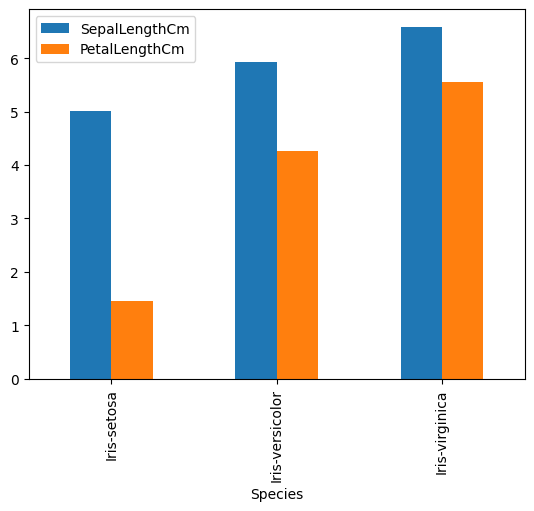

In [ ]:
temp_df.merge(df,on=['Id','Unnamed: 0']).groupby('Species').agg({'SepalLengthCm':'mean','PetalLengthCm':'mean'}).plot(kind='bar')

### `Q-10:` Create the complete dataset by uisng the below datasets:
- virginica
- versicolor
- setosa
- sepal all
- petal all

This dataset should have these below column names in order:
1. Id
2. Species
3. SepalLengthCm
4. SepalWidthCm
5. PetalLengthCm
6. PetalWidthCm

Also, the dataset should be shuffled means the `Id` column should not be in increasing or decreasing order. So, make a dataset which has the shuffled Id column. You can use `DataFrame.sample()` method to shuffle.

In [ ]:
# code here

In [ ]:
temp_df.merge(df,on=['Id','Unnamed: 0']).sample(frac=1).reset_index(drop=True)

,Unnamed: 0,Id,Species,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
0,138,139,Iris-virginica,6.0,3.0,4.8,1.8
1,145,146,Iris-virginica,6.7,3.0,5.2,2.3
2,29,30,Iris-setosa,4.7,3.2,1.6,0.2
3,77,78,Iris-versicolor,6.7,3.0,5.0,1.7
4,22,23,Iris-setosa,4.6,3.6,1.0,0.2
...,...,...,...,...,...,...,...
145,142,143,Iris-virginica,5.8,2.7,5.1,1.9
146,122,123,Iris-virginica,7.7,2.8,6.7,2.0
147,95,96,Iris-versicolor,5.7,3.0,4.2,1.2
148,71,72,Iris-versicolor,6.1,2.8,4.0,1.3


### `Q-11:` Find out the maximum and minimum sepal width and petal width of Setosa and Versicolor. To do this:
- First create a dataset with merging the required datasets
- After that, use `groupby` to create groups based on the "Species" column.
- Then find out which are asked in this question.


The output should be like this:
```bash
Minimum Sepal width of Setosa is 2.3
Maximum Sepal width of Setosa is 4.4

**************************************************

Minimum Sepal width of Versicolor is 2.0
Maximum Sepal width of Versicolor is 3.4

**************************************************
```

In [ ]:
# code here

In [ ]:
combined = temp_df.merge(df,on=['Id','Unnamed: 0']).groupby('Species').agg({'SepalWidthCm':['min','max'], 'PetalWidthCm':['min','max']}).loc['Iris-setosa':'Iris-versicolor']

In [ ]:
min_setosa = combined.loc['Iris-setosa']['SepalWidthCm']['min']
min_setosa

np.float64(2.3)